# Interventional example — triangle-linear, do(x2 = 1)

Generates data live with a simple KAN fit (no precomputed benchmark CSVs), then compares observational vs. interventional distributions.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from dowhy import gcm

from datasets.synthetic import graph_data
from models.factory import create_model_from_graph

In [3]:
dataset = 'triangle-linear'
n = 1000  # samples for training / observational / interventional sets
intervention = {'x2': lambda x: 1}  # do(x2 = 1)

data_all, data_cf_all, graph, formula_gt = graph_data(name=dataset).generate(num_samples=2 * n, seed=0)
factual_train = data_all.iloc[:n]
factual_eval = data_all.iloc[n:2 * n]

factual_eval.head()

,x1,x2,x3
1000,0.555963,0.415628,0.601415
1001,0.892474,0.861767,0.331078
1002,-0.422315,-0.405067,-1.192295
1003,0.104714,0.093363,-0.221550
1004,0.228053,0.367356,-0.652293


In [4]:
# Only overriding what's needed for a fast/simple fit; everything else falls back to
# kan_predictor's own defaults (hidden_dim=0, grid=1, k=1, lr=0.01, batch_size=500, early_stop=True, seed=0, ...).
kan_hparams = {
    'steps': 500,
    'loss': 'mse',
}

params = {node: kan_hparams for node in graph.nodes if graph.in_degree[node] > 0}
params

{'x2': {'steps': 500, 'loss': 'mse'}, 'x3': {'steps': 500, 'loss': 'mse'}}

In [5]:
model = create_model_from_graph(graph, model="kan", params=params)
gcm.fit(model, data=factual_train)

Fitting causal mechanism of node x2:   0%|          | 0/3 [00:00<?, ?it/s]

Using device: cpu


Fitting causal mechanism of node x3:  67%|██████▋   | 2/3 [00:01<00:00,  1.88it/s]

Early stopping at step 208
Using device: cpu


Fitting causal mechanism of node x3: 100%|██████████| 3/3 [00:02<00:00,  1.33it/s]


In [6]:
obs_model = gcm.draw_samples(model, num_samples=n)
obs_model = obs_model[factual_eval.columns]

int_model = gcm.interventional_samples(model, intervention, num_samples_to_draw=n)
int_model = int_model[factual_eval.columns]

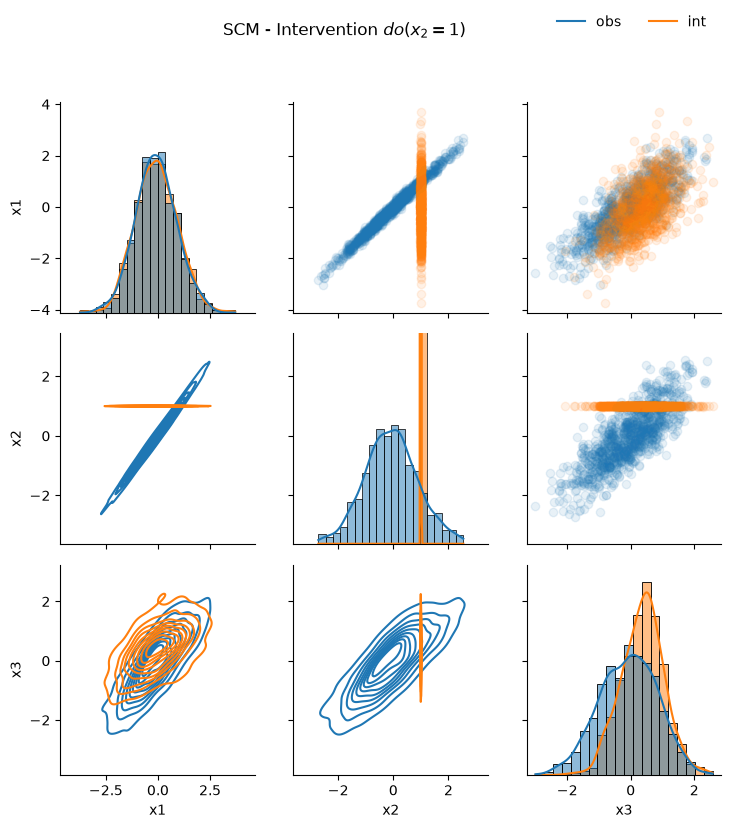

In [7]:
obs_plot = obs_model.copy()
int_plot = int_model.copy()
obs_plot['hue'] = 'obs'
int_plot['hue'] = 'int'

# x2 is pinned to a constant by the intervention; add a touch of noise so the KDE doesn't degenerate.
int_plot['x2'] = int_plot['x2'] + 0.01 * np.random.randn(len(int_plot))

data = pd.concat([obs_plot, int_plot], ignore_index=True)

g = sns.PairGrid(data, hue='hue')
g.map_upper(plt.scatter, alpha=0.1)
g.map_lower(sns.kdeplot, common_norm=False)
g.map_diag(sns.histplot, kde=True, stat='proportion', common_norm=False, bins=20)
_ = g.add_legend(bbox_to_anchor=(0.62, 1.08), loc='center left', title='', ncol=2)

for i in range(3):
            g.diag_axes[i].set_ylim((0, 0.2)) # NOTE: carefully adjust this to obtain meaningful plots, i.e., the intervention, being discrete, causes a mess

g.figure.suptitle('SCM - Intervention $do(x_2=1)$', y=1.08, x=0.4)
plt.show()

g.figure.savefig('interventional_example.pdf', bbox_inches='tight')